<a href="https://colab.research.google.com/github/CharlesSnt/PFE/blob/main/Etude_convergence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch

# MLP

In [ ]:
import numpy as np
import scipy.io
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.nn.utils import parameters_to_vector
import time

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Initialization
# -----------------------------
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


# -----------------------------
# Model Class - MLP (remplace le CNN)
# -----------------------------
class PhysicsInformedMLP(nn.Module):
    """
    MLP pour prédire directement u, v, p
    Architecture: [3] -> [20, 20, 20, 20, 20, 20, 20, 20] -> [3]
    """
    def __init__(self, layers=[3, 20, 20, 20, 20, 20, 20, 20, 20, 3]):
        super().__init__()

        self.layers_sizes = layers
        self.num_layers = len(layers) - 1

        # Construction du MLP
        self.network = nn.ModuleList()
        for i in range(self.num_layers):
            self.network.append(nn.Linear(layers[i], layers[i+1]))

        self.apply(init_weights)

    def forward(self, xyt):
        """
        Args:
            xyt: tensor de shape (N, 3) avec [x, y, t]

        Returns:
            u, v, p: tensors de shape (N, 1) chacun
        """
        # Si xyt a des dimensions supplémentaires (comme dans ton code avec unsqueeze)
        # on les aplatit d'abord
        if xyt.dim() > 2:
            original_shape = xyt.shape
            xyt = xyt.view(-1, 3)
            needs_reshape = True
        else:
            needs_reshape = False

        h = xyt

        # Propagation à travers les couches cachées avec tanh
        for i in range(self.num_layers - 1):
            h = torch.tanh(self.network[i](h))

        # Dernière couche (linéaire)
        out = self.network[-1](h)

        # Séparer u, v, p
        u = out[:, 0:1]
        v = out[:, 1:2]
        p = out[:, 2:3]

        # Remettre la forme originale si nécessaire
        if needs_reshape:
            u = u.view(original_shape[0], 1, original_shape[2], original_shape[3])
            v = v.view(original_shape[0], 1, original_shape[2], original_shape[3])
            p = p.view(original_shape[0], 1, original_shape[2], original_shape[3])

        return u, v, p


# -----------------------------
# Physics (Navier-Stokes) - CORRIGÉ
# -----------------------------
def navier_stokes_residual(model, xyt, nu=0.01):
    """
    Calcule les résidus de Navier-Stokes
    CORRECTION: Ajoute l'équation de continuité pour l'incompressibilité
    """
    # Aplatir si nécessaire
    if xyt.dim() > 2:
        batch_size = xyt.shape[0]
        xyt = xyt.view(batch_size, 3)

    xyt.requires_grad_(True)

    # Prédiction du modèle
    u, v, p = model(xyt)

    # Aplatir les sorties si elles ont des dimensions supplémentaires
    if u.dim() > 2:
        u = u.view(-1, 1)
        v = v.view(-1, 1)
        p = p.view(-1, 1)

    # Dérivées de u
    u_g = autograd.grad(u, xyt, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x, u_y, u_t = u_g[:, 0:1], u_g[:, 1:2], u_g[:, 2:3]

    # Dérivées de v
    v_g = autograd.grad(v, xyt, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_x, v_y, v_t = v_g[:, 0:1], v_g[:, 1:2], v_g[:, 2:3]

    # Dérivées de p
    p_g = autograd.grad(p, xyt, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_g[:, 0:1], p_g[:, 1:2]

    # Dérivées secondes de u
    u_xx = autograd.grad(
        u_x, xyt, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0][:, 0:1]
    u_yy = autograd.grad(
        u_y, xyt, grad_outputs=torch.ones_like(u_y), create_graph=True
    )[0][:, 1:2]

    # Dérivées secondes de v
    v_xx = autograd.grad(
        v_x, xyt, grad_outputs=torch.ones_like(v_x), create_graph=True
    )[0][:, 0:1]
    v_yy = autograd.grad(
        v_y, xyt, grad_outputs=torch.ones_like(v_y), create_graph=True
    )[0][:, 1:2]

    # Résidus de Navier-Stokes
    f_u = u_t + u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    f_v = v_t + u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)

    # CORRECTION: Équation de continuité (incompressibilité)
    f_continuity = u_x + v_y

    return f_u, f_v, f_continuity, u, v, p

#ancienne fonctions de pertes (les 2 pertes sont calculées sur les mêmes points)

def pinn_loss2(model, xyt, u_true, v_true, nu=0.01):
   """
   Fonction de perte PINN complète
   """
   f_u, f_v, f_continuity, u_pred, v_pred, _ = navier_stokes_residual(model, xyt, nu)

    # Aplatir si nécessaire pour le calcul de perte
   if u_pred.dim() > 2:
        u_pred = u_pred.view(-1, 1)
        v_pred = v_pred.view(-1, 1)
   if u_true.dim() > 2:
        u_true = u_true.view(-1, 1)
        v_true = v_true.view(-1, 1)

    # Perte sur les données
   mse_data = ((u_pred - u_true) ** 2).mean() + ((v_pred - v_true) ** 2).mean()

    # Perte sur les résidus physiques (équations de NS + continuité)
   mse_pde = (f_u**2).mean() + (f_v**2).mean() + (f_continuity**2).mean()

   return mse_data + mse_pde

#Nouvelle fonction de perte (les loss ne sont pas calculées sur les mêmes points)
def pinn_loss(model, xyt_data, u_true, v_true, xyt_colloc, nu=0.01):

    # 1. Loss données : sur tes 50 points supervisés
    _, _, _, u_pred, v_pred, _ = navier_stokes_residual(model, xyt_data, nu)
    mse_data = ((u_pred - u_true)**2).mean() + ((v_pred - v_true)**2).mean()

    # 2. Loss PDE : sur les points de collocation rééchantillonnés
    f_u, f_v, f_cont, _, _, _ = navier_stokes_residual(model, xyt_colloc, nu)
    mse_pde = (f_u**2).mean() + (f_v**2).mean() + (f_cont**2).mean()

    return mse_data + mse_pde

# -----------------------------
# Generic Training Function
# -----------------------------
def run_training_session(mode_name, xyt, u_true, v_true, steps=2000, use_lbfgs=False):
    """
    Lance un entraînement complet selon le mode spécifié.
    Modes: 'adam', 'sgd'
    """
    print(f"\n=== Start to train : {mode_name} (LBFGS={use_lbfgs}) ===")

    # Utiliser le MLP au lieu du CNN
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)

    if "sgd" in mode_name.lower():
        optimizer = optim.SGD(model.parameters(), lr=1e-2)
    else:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

    weight_history = []

    # --- Principal loop (Adam / SGD) ---
    for it in range(steps):
        optimizer.zero_grad()
        loss = pinn_loss(model, xyt, u_true, v_true)
        loss.backward()
        optimizer.step()

        if it % 50 == 0:
            current_w = parameters_to_vector(model.parameters()).detach().cpu()
            weight_history.append(current_w)
            if it % 500 == 0:
                print(f"Iter {it}, Loss: {loss.item():.3e}")

    weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())

    # --- Phase LBFGS (Optionnal) ---
    if use_lbfgs:
        print("Début LBFGS...")
        optimizer_lbfgs = optim.LBFGS(
            model.parameters(),
            max_iter=500,
            tolerance_grad=1e-9,
            tolerance_change=1e-9,
            history_size=50,
            line_search_fn="strong_wolfe",
        )

        def closure():
            optimizer_lbfgs.zero_grad()
            loss = pinn_loss(model, xyt, u_true, v_true)
            loss.backward()
            return loss

        optimizer_lbfgs.step(closure)

        weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())

    # Save the loss functions
    suffix = "_lbfgs" if use_lbfgs else ""
    filename_base = f"navier_{mode_name}{suffix}"

    torch.save(model.state_dict(), f"{filename_base}_model.pth")
    torch.save(torch.stack(weight_history), f"{filename_base}_traj.pt")
    print(f"Sauvegardé : {filename_base}_model.pth et .pt")

In [ ]:
def sample_collocation(N, T, N_colloc, x,  y, t):
  idx_colloc = np.random.choice(N * T, N_colloc, replace=False)
  x_colloc = torch.tensor(x[idx_colloc, :], dtype=torch.float32)
  y_colloc = torch.tensor(y[idx_colloc, :], dtype=torch.float32)
  t_colloc = torch.tensor(t[idx_colloc, :], dtype=torch.float32)
  # ← pas de u_colloc / v_colloc, on n'en a pas besoin !

  xyt_colloc = torch.cat([x_colloc, y_colloc, t_colloc], dim=1)
  xyt_colloc.requires_grad_(True)
  xyt_colloc = xyt_colloc.to(device)

  return xyt_colloc

def sample_data(N, T, N_sample, x, y, t, u, v):
    idx = np.random.choice(N * T, N_train, replace=False)

    x_train = torch.tensor(x[idx, :], dtype=torch.float32)
    y_train = torch.tensor(y[idx, :], dtype=torch.float32)
    t_train = torch.tensor(t[idx, :], dtype=torch.float32)
    u_train = torch.tensor(u[idx, :], dtype=torch.float32)
    v_train = torch.tensor(v[idx, :], dtype=torch.float32)

    # Pour le MLP, on n'a pas besoin des unsqueeze supplémentaires
    xyt_train = torch.cat([x_train, y_train, t_train], dim=1)
    xyt_train.requires_grad_(True)

    xyt_train = xyt_train.to(device)
    u_train = u_train.to(device)
    v_train = v_train.to(device)
    return xyt_train, u_train, v_train

In [ ]:
# -----------------------------
# Training Function ADAM + LBFGS
# -----------------------------
def run_training_session_ADAM_LBFGS(N, T, N_colloc, x,  y, t, N_sample, steps=2000):
    """
    Lance un entraînement complet en utilisant ADAM et LBFGS
    """
    print(f"\n=== Start to train : ADAM+LBFGS")
    start_time = time.time()

    # Utiliser le MLP au lieu du CNN
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    weight_history = []
    loss_history = []


    # --- Principal loop (Adam / SGD) ---
    for it in range(steps):
        optimizer.zero_grad()
        # Rééchantillonnage à chaque itération
        xyt_colloc = sample_collocation(N, T, N_colloc, x,  y, t)
        xyt_train, u_train, v_train = sample_data(N, T, N_sample, x, y, t, u, v)
        loss = pinn_loss(model, xyt_train, u_train, v_train, xyt_colloc)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        if it % 50 == 0:
            current_w = parameters_to_vector(model.parameters()).detach().cpu()
            weight_history.append(current_w)
            if it % 500 == 0:
                print(f"Iter {it}, Loss: {loss.item():.3e}")

    weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())

    # --- Phase LBFGS (Optionnal) ---
    print("Début LBFGS...")
    optimizer_lbfgs = optim.LBFGS(
          model.parameters(),
          max_iter=500,
          tolerance_grad=1e-9,
          tolerance_change=1e-9,
          history_size=50000,
          line_search_fn="strong_wolfe",
        )

    def closure():
          optimizer_lbfgs.zero_grad()
          xyt_colloc = sample_collocation(N, T, N_colloc, x,  y, t)
          xyt_train, u_train, v_train = sample_data(N, T, N_sample, x, y, t, u, v)
          loss = pinn_loss(model, xyt_train, u_train, v_train, xyt_colloc)
          loss.backward()
          loss_history.append(loss.item())
          return loss

    optimizer_lbfgs.step(closure)

    weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())
    elapsed_time = time.time() - start_time
    return weight_history, loss_history, elapsed_time

In [ ]:
# -----------------------------
# Training Function ADAM
# -----------------------------
def run_training_session_ADAM(N, T, N_colloc, x,  y, t, N_sample, steps=2000):
    """
    Lance un entraînement complet en utilisant ADAM
    """
    print(f"\n=== Start to train : ADAM")
    start_time = time.time()

    # Utiliser le MLP au lieu du CNN
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    weight_history = []
    loss_history = []
    #loss = pinn_loss(model, xyt, u_true, v_true)
    #loss_history.append(loss.item())

    # --- Principal loop (Adam / SGD) ---
    for it in range(steps):
        optimizer.zero_grad()
        # Rééchantillonnage à chaque itération
        xyt_colloc = sample_collocation(N, T, N_colloc, x,  y, t)
        xyt_train, u_train, v_train = sample_data(N, T, N_sample, x, y, t, u, v)
        loss = pinn_loss(model, xyt_train, u_train, v_train, xyt_colloc)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        if it % 50 == 0:
            current_w = parameters_to_vector(model.parameters()).detach().cpu()
            weight_history.append(current_w)
            if it % 500 == 0:
                print(f"Iter {it}, Loss: {loss.item():.3e}")

    weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())
    elapsed_time = time.time() - start_time
    return weight_history, loss_history, elapsed_time

In [ ]:
# -----------------------------
# Training Function LBFGS
# -----------------------------
def run_training_session_LBFGS(N, T, N_colloc, x,  y, t, N_sample, max_iter=2000):
    """
    Lance un entraînement complet en utilisant LBFGS
    """
    print(f"\n=== Start to train : LBFGS")
    start_time = time.time()

    # Utiliser le MLP au lieu du CNN
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)

    weight_history = []
    loss_history = []

    # --- Principal loop (Adam / SGD) ---

    print("Début LBFGS...")
    optimizer_lbfgs = optim.LBFGS(
          model.parameters(),
          max_iter=max_iter,
          tolerance_grad=1e-9,
          tolerance_change=1e-9,
          history_size=50,
          line_search_fn="strong_wolfe",
        )

    def closure():
          optimizer_lbfgs.zero_grad()
          xyt_colloc = sample_collocation(N, T, N_colloc, x,  y, t)
          xyt_train, u_train, v_train = sample_data(N, T, N_sample, x, y, t, u, v)
          loss = pinn_loss(model, xyt_train, u_train, v_train, xyt_colloc)
          loss.backward()
          loss_history.append(loss.item())
          return loss

    optimizer_lbfgs.step(closure)

    weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())
    elapsed_time = time.time() - start_time
    return weight_history, loss_history, elapsed_time

In [ ]:
# -----------------------------
# Training session using SGD
# -----------------------------
def run_training_session_SGD(N, T, N_colloc, x,  y, t, N_sample, steps=2000):
    """
    Lance un entraînement complet de 'sgd'
    """

    print(f"\n=== Start to train : SGD")
    start_time = time.time()

    # Utiliser le MLP au lieu du CNN
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)

    optimizer = optim.SGD(model.parameters(), lr=1e-2)

    weight_history = []
    loss_history = []

    # --- Principal loop (Adam / SGD) ---
    for it in range(steps):
        optimizer.zero_grad()
        xyt_colloc = sample_collocation(N, T, N_colloc, x,  y, t)
        xyt_train, u_train, v_train = sample_data(N, T, N_sample, x, y, t, u, v)
        loss = pinn_loss(model, xyt_train, u_train, v_train, xyt_colloc)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        if it % 50 == 0:
            current_w = parameters_to_vector(model.parameters()).detach().cpu()
            weight_history.append(current_w)
            if it % 500 == 0:
                print(f"Iter {it}, Loss: {loss.item():.3e}")

    weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())
    elapsed_time = time.time() - start_time
    return weight_history, loss_history, elapsed_time

In [ ]:

# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":
    # Load Data
    data = scipy.io.loadmat("/content/cylinder_nektar_wake.mat")
    U_star = data["U_star"]
    t_star = data["t"]
    X_star = data["X_star"]

    N = X_star.shape[0]
    T = t_star.shape[0]

    XX = np.tile(X_star[:, 0:1], (1, T))
    YY = np.tile(X_star[:, 1:2], (1, T))
    TT = np.tile(t_star, (1, N)).T
    UU = U_star[:, 0, :]
    VV = U_star[:, 1, :]

    x = XX.flatten()[:, None]
    y = YY.flatten()[:, None]
    t = TT.flatten()[:, None]
    u = UU.flatten()[:, None]
    v = VV.flatten()[:, None]

    # Training Data Selection
    N_train = 5000
    idx = np.random.choice(N * T, N_train, replace=False)

    x_train = torch.tensor(x[idx, :], dtype=torch.float32)
    y_train = torch.tensor(y[idx, :], dtype=torch.float32)
    t_train = torch.tensor(t[idx, :], dtype=torch.float32)
    u_train = torch.tensor(u[idx, :], dtype=torch.float32)
    v_train = torch.tensor(v[idx, :], dtype=torch.float32)

    # Pour le MLP, on n'a pas besoin des unsqueeze supplémentaires
    xyt_train = torch.cat([x_train, y_train, t_train], dim=1)
    xyt_train.requires_grad_(True)

    xyt_train = xyt_train.to(device)
    u_train = u_train.to(device)
    v_train = v_train.to(device)



Etude de convergence de 4 algorithmes d'optimisation

In [ ]:
loss_adam_lbfgs = []
loss_adam = []
loss_lbfgs = []
loss_sgd = []
time_adam_lbfgs = []
time_adam = []
time_lbfgs = []
time_sgd = []

N_colloc = 50
N_sample = 50

# 1. Adam + LBFGS (Original one)
w_adam_lbfgs, loss_hist_adam_lbfgs, t_adam_lbfgs = run_training_session_ADAM_LBFGS(
       N, T, N_colloc, x,  y, t, N_sample, steps=2000)
loss_adam_lbfgs.append(loss_hist_adam_lbfgs)
time_adam_lbfgs.append(t_adam_lbfgs)

# 2. Adam seul (Without LBFGS)
w_adam, loss_hist_adam, t_adam = run_training_session_ADAM(N, T, N_colloc, x,  y, t,
         N_sample, steps=2000)
loss_adam.append(loss_hist_adam)
time_adam.append(t_adam)

# 3. LBFGS seul
w_lbfgs, loss_hist_lbfgs, t_lbfgs = run_training_session_LBFGS(
        N, T, N_colloc, x,  y, t, N_sample, max_iter=2000)
loss_lbfgs.append(loss_hist_lbfgs)
time_lbfgs.append(t_lbfgs)

# 4. Gradient Descent (SGD)
w_sgd, loss_hist_sgd, t_sgd = run_training_session_SGD(
    N, T, N_colloc, x,  y, t, N_sample, steps=2000)
loss_sgd.append(loss_hist_sgd)
time_sgd.append(t_sgd)


=== Start to train : ADAM+LBFGS
Iter 0, Loss: 2.032e+00
Iter 500, Loss: 1.071e-01
Iter 1000, Loss: 9.804e-02
Iter 1500, Loss: 9.562e-02
Début LBFGS...

=== Start to train : ADAM
Iter 0, Loss: 4.741e-01
Iter 500, Loss: 9.631e-02
Iter 1000, Loss: 8.185e-02
Iter 1500, Loss: 7.391e-02

=== Start to train : LBFGS
Début LBFGS...

=== Start to train : SGD
Iter 0, Loss: 6.236e-01
Iter 500, Loss: 1.593e-01
Iter 1000, Loss: 1.559e-01
Iter 1500, Loss: 1.523e-01


In [ ]:
import matplotlib.pyplot as plt

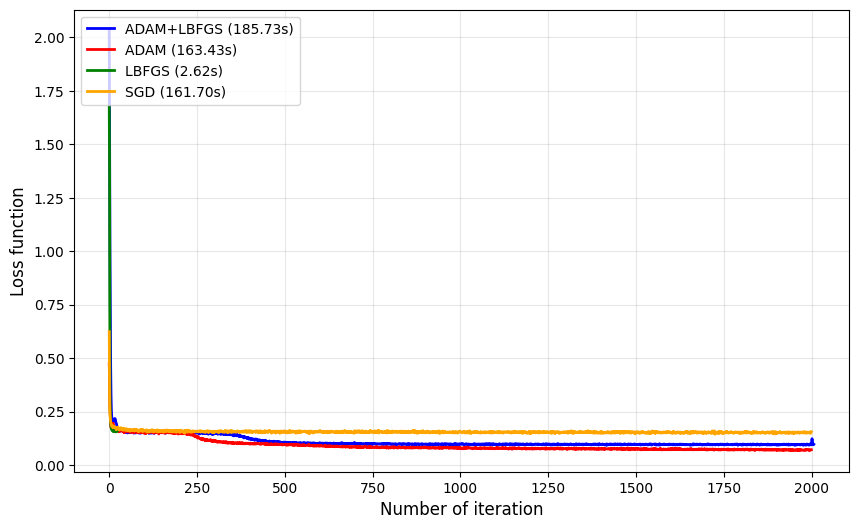

In [ ]:
plt.figure(figsize=(10, 6))  # Taille du graphique

# Différents styles de lignes et couleurs
plt.plot(loss_adam_lbfgs[0], label=f'ADAM+LBFGS ({time_adam_lbfgs[0]:.2f}s)', color='blue', linewidth=2)
plt.plot(loss_adam[0], color='red', label=f'ADAM ({time_adam[0]:.2f}s)', linewidth=2)
plt.plot(loss_lbfgs[0], label=f'LBFGS ({time_lbfgs[0]:.2f}s)', color='green', linewidth=2)
plt.plot(loss_sgd[0], label=f'SGD ({time_sgd[0]:.2f}s)', color='orange', linewidth=2)

plt.xlabel('Number of iteration', fontsize=12)
plt.ylabel('Loss function', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

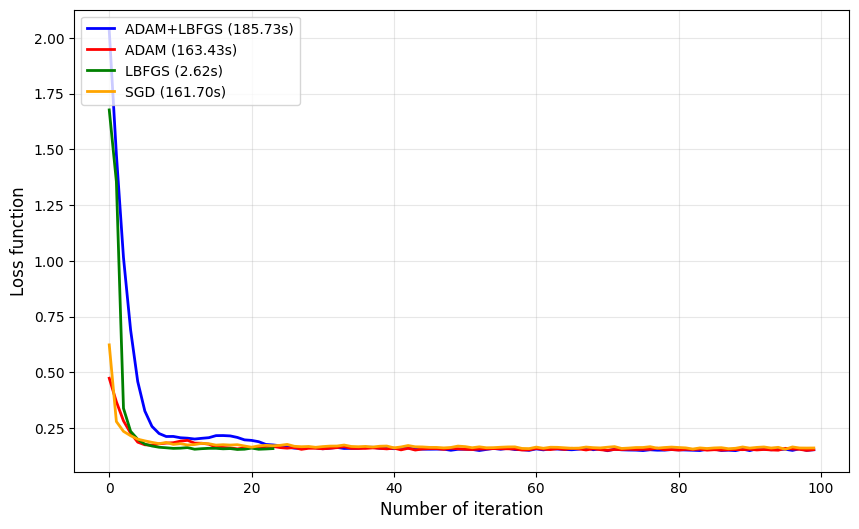

In [ ]:
plt.figure(figsize=(10, 6))  # Taille du graphique

# Différents styles de lignes et couleurs
plt.plot(loss_adam_lbfgs[0][0:100], label=f'ADAM+LBFGS ({time_adam_lbfgs[0]:.2f}s)', color='blue', linewidth=2)
plt.plot(loss_adam[0][0:100], color='red', label=f'ADAM ({time_adam[0]:.2f}s)', linewidth=2)
plt.plot(loss_lbfgs[0][0:100], label=f'LBFGS ({time_lbfgs[0]:.2f}s)', color='green', linewidth=2)
plt.plot(loss_sgd[0][0:100], label=f'SGD ({time_sgd[0]:.2f}s)', color='orange', linewidth=2)

plt.xlabel('Number of iteration', fontsize=12)
plt.ylabel('Loss function', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

# Plotting

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from torch.nn.utils import parameters_to_vector, vector_to_parameters
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Utilitary functions
# -----------------------------
def get_projection_directions(w_final, w_init):
    vec_main = w_init - w_final
    norm_main = torch.norm(vec_main)
    if norm_main < 1e-6:
        dir_x = torch.randn_like(w_final)
    else:
        dir_x = vec_main / norm_main

    random_vec = torch.randn_like(w_final)
    dir_y = random_vec - torch.dot(random_vec, dir_x) * dir_x
    dir_y = dir_y / (torch.norm(dir_y) + 1e-10)
    return dir_x, dir_y


def project_trajectory(history, w_final, dir_x, dir_y):
    traj_x, traj_y = [], []
    w_final_cpu = w_final.cpu()
    dir_x_cpu, dir_y_cpu = dir_x.cpu(), dir_y.cpu()

    for w in history:
        diff = w - w_final_cpu
        traj_x.append(torch.dot(diff, dir_x_cpu).item())
        traj_y.append(torch.dot(diff, dir_y_cpu).item())
    return traj_x, traj_y


def generate_landscape_plot(
    model_path, traj_path, title, output_filename, xyt_val, u_val, v_val
):
    """Generating the loss landscape"""
    print(f"\n--- Traitement Landscape : {title} ---")

    # Architecture du MLP (même que dans l'entraînement)
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)

    if not os.path.exists(model_path) or not os.path.exists(traj_path):
        print(f"Missing file for {title}.")
        return

    model.load_state_dict(torch.load(model_path, map_location=device))
    w_final = parameters_to_vector(model.parameters()).detach()
    history = torch.load(traj_path, map_location="cpu")

    w_init = history[0].to(device)
    dir_x, dir_y = get_projection_directions(w_final, w_init)
    traj_x, traj_y = project_trajectory(history, w_final, dir_x, dir_y)

    x_min, x_max = min(traj_x), max(traj_x)
    y_min, y_max = min(traj_y), max(traj_y)
    span_x = max((x_max - x_min), 0.1) * 0.2
    span_y = max((y_max - y_min), 0.1) * 0.5

    res = 25
    alphas = np.linspace(x_min - span_x, x_max + span_x, res)
    betas = np.linspace(-span_y - 0.1, span_y + 0.1, res)
    loss_grid = np.zeros((res, res))

    dir_x, dir_y = dir_x.to(device), dir_y.to(device)

    print("Calcul de la Loss Landscape...")
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            vec = w_final + a * dir_x + b * dir_y
            vector_to_parameters(vec, model.parameters())
            l = pinn_loss(model, xyt_val, u_val, v_val).item()
            loss_grid[i, j] = np.log10(l + 1e-10)

    vector_to_parameters(w_final, model.parameters())

    X, Y = np.meshgrid(alphas, betas)
    plt.figure(figsize=(10, 8))
    cp = plt.contourf(X, Y, loss_grid.T, levels=30, cmap="Spectral_r")
    plt.colorbar(cp, label="Log10(Loss)")
    plt.plot(traj_x, traj_y, color="white", linestyle="--", linewidth=1.5, alpha=0.8)
    plt.scatter(traj_x[0], traj_y[0], c="white", marker="o", s=50, label="Début")
    plt.scatter(0, 0, c="black", marker="*", s=200, label="Fin (Min)")
    plt.title(f"Loss Landscape : {title}")
    plt.legend()
    plt.savefig(output_filename, dpi=300)
    plt.close()
    print(f"Sauvegardé : {output_filename}")


def plot_pressure_field(
    model_path, data, snap_idx=100, output_name="pressure_comparison.png"
):
    print(f"\n--- Generating the pressure plot ({output_name}) ---")

    if not os.path.exists(model_path):
        print(f"Modèle {model_path} introuvable.")
        return

    X_star = data["X_star"]  # Spatial coordinates (N, 2)
    t_star = data["t"]  # Time (T, 1)
    P_star = data["p_star"]  # Exact pressure (N, T)

    x_star = X_star[:, 0:1]
    y_star = X_star[:, 1:2]
    t_fixed = t_star[snap_idx, 0]

    xx = torch.tensor(x_star, dtype=torch.float32).to(device)
    yy = torch.tensor(y_star, dtype=torch.float32).to(device)
    tt = torch.tensor(np.full_like(x_star, t_fixed), dtype=torch.float32).to(device)

    # Pour le MLP: pas besoin de unsqueeze supplémentaires
    xyt = torch.cat([xx, yy, tt], dim=1)

    # Créer le modèle MLP
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        _, _, p_pred_tensor = model(xyt)
        # Aplatir si nécessaire
        if p_pred_tensor.dim() > 2:
            p_pred = p_pred_tensor.squeeze().cpu().numpy()
        else:
            p_pred = p_pred_tensor.cpu().numpy().flatten()

    p_exact = P_star[:, snap_idx]

    lb = X_star.min(0)
    ub = X_star.max(0)
    nn_grid = 200
    x_space = np.linspace(lb[0], ub[0], nn_grid)
    y_space = np.linspace(lb[1], ub[1], nn_grid)
    X, Y = np.meshgrid(x_space, y_space)

    P_pred_grid = griddata(X_star, p_pred.flatten(), (X, Y), method="cubic")
    P_exact_grid = griddata(X_star, p_exact.flatten(), (X, Y), method="cubic")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # -- Predicted --
    h1 = ax[0].imshow(
        P_pred_grid,
        interpolation="nearest",
        cmap="rainbow",
        extent=[lb[0], ub[0], lb[1], ub[1]],
        origin="lower",
        aspect="auto",
    )
    fig.colorbar(h1, ax=ax[0])
    ax[0].set_title("Predicted pressure")
    ax[0].set_xlabel("$x$")
    ax[0].set_ylabel("$y$")

    # -- Exact --
    h2 = ax[1].imshow(
        P_exact_grid,
        interpolation="nearest",
        cmap="rainbow",
        extent=[lb[0], ub[0], lb[1], ub[1]],
        origin="lower",
        aspect="auto",
    )
    fig.colorbar(h2, ax=ax[1])
    ax[1].set_title("Exact pressure")
    ax[1].set_xlabel("$x$")
    ax[1].set_ylabel("$y$")

    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    plt.show()
    print(f"Sauvegardé : {output_name}")


In [ ]:


# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":

    print("Loading the data...")
    try:
        data = scipy.io.loadmat("/content/cylinder_nektar_wake.mat")
    except FileNotFoundError:
        print("Erreur: /content/cylinder_nektar_wake.mat introuvable.")
        exit()

    U_star = data["U_star"]
    t_star = data["t"]
    X_star = data["X_star"]

    N_val = 20
    idx = np.random.choice(X_star.shape[0] * t_star.shape[0], N_val, replace=False)

    XX = np.tile(X_star[:, 0:1], (1, t_star.shape[0])).flatten()
    YY = np.tile(X_star[:, 1:2], (1, t_star.shape[0])).flatten()
    TT = np.tile(t_star, (1, X_star.shape[0])).T.flatten()
    UU = U_star[:, 0, :].flatten()
    VV = U_star[:, 1, :].flatten()

    x_val = torch.tensor(XX[idx][:, None], dtype=torch.float32).to(device)
    y_val = torch.tensor(YY[idx][:, None], dtype=torch.float32).to(device)
    t_val = torch.tensor(TT[idx][:, None], dtype=torch.float32).to(device)
    u_val = torch.tensor(UU[idx][:, None], dtype=torch.float32).to(device)
    v_val = torch.tensor(VV[idx][:, None], dtype=torch.float32).to(device)

    # Pour le MLP: pas de unsqueeze supplémentaires
    xyt_val = torch.cat([x_val, y_val, t_val], dim=1)
    xyt_val.requires_grad_(True)

    # u_val et v_val restent (N, 1) pour le MLP

    # ---------------------------------------------------------
    # Generating landscapes
    # ---------------------------------------------------------
    generate_landscape_plot(
        "/content/navier_adam_lbfgs_model.pth",
        "/content/navier_adam_lbfgs_traj.pt",
        "Adam + LBFGS",
        "/content/landscape_adam_lbfgs.png",
        xyt_val,
        u_val,
        v_val,
    )

    generate_landscape_plot(
        "/content/navier_adam_only_model.pth",
        "/content/navier_adam_only_traj.pt",
        "/content/Adam Only",
        "/content/landscape_adam_only.png",
        xyt_val,
        u_val,
        v_val,
    )

    generate_landscape_plot(
        "/content/navier_sgd_model.pth",
        "/content/navier_sgd_traj.pt",
        "SGD",
        "/content/landscape_sgd.png",
        xyt_val,
        u_val,
        v_val,
    )

    # ---------------------------------------------------------
    # Pressure Graph
    # ---------------------------------------------------------

    plot_pressure_field(
        model_path="/content/navier_adam_lbfgs_model.pth",
        data=data,
        snap_idx=100,
        output_name="/content/pressure_comparison_adam_lbfgs.png",
    )

Loading the data...

--- Traitement Landscape : Adam + LBFGS ---
Missing file for Adam + LBFGS.

--- Traitement Landscape : /content/Adam Only ---
Missing file for /content/Adam Only.

--- Traitement Landscape : SGD ---
Missing file for SGD.

--- Generating the pressure plot (/content/pressure_comparison_adam_lbfgs.png) ---
Modèle /content/navier_adam_lbfgs_model.pth introuvable.
